In [10]:

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as np
from jax import vmap, jit

import numpy as onp
#from scipy.integrate import odeint
#from scipy.special import gammaln
import pandas as pd
from matplotlib import pyplot as plt
import os

# modules from particles
import particles  # core module
from particles import distributions as dists  # where probability distributions are defined
from particles import state_space_models as ssm  # where state-space models are defined
from particles.collectors import Moments
from particles import mcmc  # where the MCMC algorithms (PMMH, Particle Gibbs, etc) live

from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt, PIDController


In [11]:
## particles only works with an old version of scipy

%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Thu, 01 Oct 2026

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.17.1

diffrax   : 0.7.2
jax       : 0.5.3
matplotlib: 3.11.2
numpy     : 1.26.4
pandas    : 3.0.6
particles : 0.4

Watermark: 2.6.0



In [12]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-paper')
plt.style.use('dark_background')


In [13]:
## diffrax ode solvers, from docs
def f(t, y, args):
    return -y
y0 = np.array([2., 3.])
ts = np.linspace(0.,3.,4)
term = ODETerm(f)
solver = Tsit5()
solution = diffeqsolve(term, solver, t0=ts[0], t1=ts[-1], dt0=None, y0=y0, 
                       #args=p,
                       saveat=SaveAt(ts=ts), 
                       stepsize_controller=PIDController(rtol=1e-5, atol=1e-5))
solution.ys

Array([[2.        , 3.        ],
       [0.73576137, 1.10364206],
       [0.27067213, 0.40600819],
       [0.09957585, 0.14936378]], dtype=float64)

In [14]:
## messing with example from website

class BearingsOnly(ssm.StateSpaceModel):
    default_params = {'sigmaX': 0.1,
                      'sigmaY': 0.1,
                      'x0': np.array([3e-3, -3e-3, 1., 1.])
                     }

    def onestep(self,s,sig):
        return [s[0]+s[2], s[1]+s[3], s[2]+sig, s[3]-sig]
        
    def PX0(self):
        return dists.IndepProd(dists.Dirac(loc=self.x0[0]),
                               dists.Dirac(loc=self.x0[1]),
                               dists.Dirac(loc=self.x0[2]),
                               dists.Dirac(loc=self.x0[3]),
                               )

    def PX(self, t, xp):
        #by particle
        #totals = np.stack([np.array(self.onestep(s,self.sigmaX)) for s in xp])
        #components = [dists.Dirac(loc=totals[:, j]) for j in range(totals.shape[1])]

        #vectorized function
        columns = [xp[:,0], xp[:,1], xp[:,2], xp[:,3]]
        totals = self.onestep(columns, self.sigmaX)
        components = [dists.Dirac(X) for X in totals]

        #original
        #components = [dists.Dirac(loc=xp[:, 0] + xp[:, 2]),
        #              dists.Dirac(loc=xp[:, 1] + xp[:, 3]),
        #              dists.Dirac(loc=xp[:, 2] + self.sigmaX), #dists.Normal(loc=xp[:, 2], scale=self.sigmaX),
        #              dists.Dirac(loc=xp[:, 3] - self.sigmaX),] #dists.Normal(loc=xp[:, 3], scale=self.sigmaX),
        #     
        #                                   
        return dists.IndepProd(*components)

    def PY(self, t, xp, x):
        angle = np.arctan(x[:, 0] / x[:, 1])
        angle = np.where(x[:, 1] < 0, angle+np.pi, angle)
        #angle[x[:, 1] < 0.] += np.pi
        return dists.Normal(loc=angle, scale=self.sigmaY)



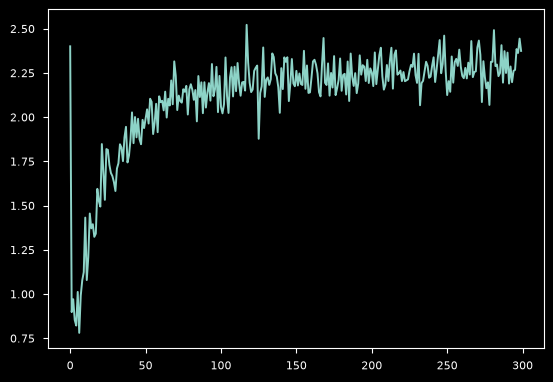

In [15]:
bear = BearingsOnly()
x, y = bear.simulate(300)
bear_out = np.array(y)
plt.plot(bear_out);

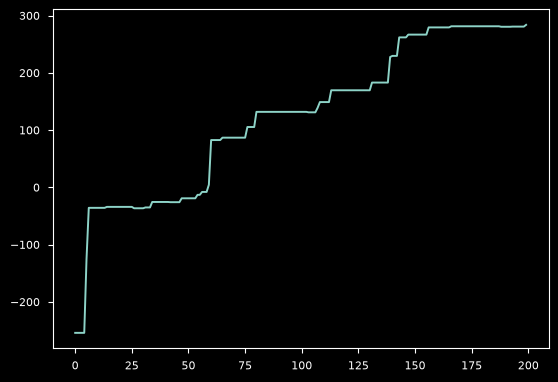

In [16]:
pmmh = mcmc.PMMH(ssm_cls=BearingsOnly, prior=dists.StructDist(
                 {'sigmaX':dists.Gamma(),'sigmaY':dists.Gamma()}),
                  data=bear_out, Nx=50, niter = 200)
pmmh.run()
plt.plot(pmmh.chain.lpost);

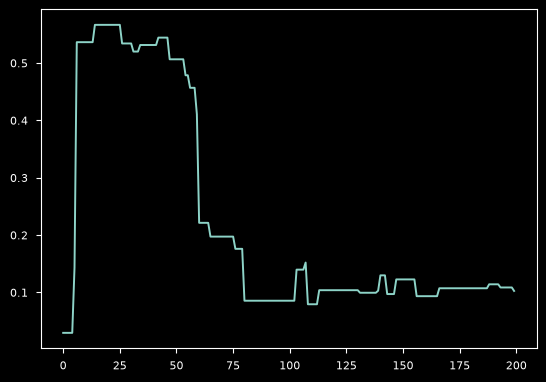

In [17]:
plt.plot(pmmh.chain.theta['sigmaX']);

In [18]:
## example converted to structdist
class StructDist_example(ssm.StateSpaceModel):
    default_params = {'sigmaX': 0.2,
                      'sigmaY': 1e-6,
                      'x0': {'a':3e-3, 'b':-3e-3, 'c':1., 'd':1.}
                     }

    def PX0(self):
        return dists.StructDist({'a':dists.Dirac(loc=self.x0['a']),
                               'b':dists.Dirac(loc=self.x0['b']),
                               'c':dists.Normal(loc=self.x0['c'], scale=self.sigmaX),
                               'd':dists.Normal(loc=self.x0['d'], scale=self.sigmaX),}
                               )

    def PX(self, t, xp):
        return dists.StructDist({'a':dists.Dirac(loc=xp['a'] + xp['c']),
                                 'b':dists.Dirac(loc=xp['b'] + xp['d']),
                                 'c':dists.Normal(loc=xp['c'], scale=self.sigmaX),
                                 'd':dists.Normal(loc=xp['d'], scale=self.sigmaX),}
                                )

    def PY(self, t, xp, x):
        angle = np.arctan(x['a'] / x['b'])
        angle[x['b'] < 0.] += np.pi
        return dists.Normal(loc=angle, scale=self.sigmaY)


In [ ]:

# we will carry out the simulations on proportions, and convert to per 100K rates
@jit
def competing_flu(t, x, p):
    # unpack vectors
    beta_A, beta_B, gamma_A, gamma_B, epsilon, theta_A, theta_B, mu = p
    S, S_A, S_B, V, I_A, I_B, H_A, H_B, R, H_A_cum, H_B_cum = x

    # Force of infection
    lambda_A = beta_A * I_A
    lambda_B = beta_B * I_B

    dS_dt = -(lambda_A + lambda_B)*S
    dS_A_dt = -(lambda_A + epsilon*lambda_B)*S_A
    dS_B_dt = -(epsilon*lambda_A + lambda_B)*S_B
    dV_dt = -epsilon*(lambda_A + lambda_B)*V
    dI_A_dt = lambda_A*(S + S_A + epsilon*(S_B + V)) - gamma_A*I_A
    dI_B_dt = lambda_B*(S + S_B + epsilon*(S_A + V)) - gamma_B*I_B
    dH_A_dt = gamma_A*theta_A*I_A - mu*H_A
    dH_B_dt = gamma_B*theta_B*I_B - mu*H_B
    dR_dt = gamma_A*(1 - theta_A)*I_A + gamma_B*(1 - theta_B)*I_B + mu*(H_A+H_B)
    dH_A_cum_dt = gamma_A*theta_A*I_A
    dH_B_cum_dt = gamma_B*theta_B*I_B

    return np.array([dS_dt,dS_A_dt,dS_B_dt,dV_dt,dI_A_dt,dI_B_dt,dH_A_dt,dH_B_dt,dR_dt,dH_A_cum_dt,dH_B_cum_dt])

## create objects for ode solver
odeterm = ODETerm(competing_flu)
odesolver = Tsit5()
odestepsize = PIDController(rtol=1e-6, atol=1e-6)

## used in PX() of state space model:
@jit
def onestep(prev, p):
    deltaT = 7.0
    ## leaving out "saveat" saves only t1
    next = diffeqsolve(odeterm, odesolver, t0=0., t1=deltaT, dt0=None, y0=prev, args=p, stepsize_controller=odestepsize)
    return next.ys[0]

## vectorizes and jax-compiles onestep() for calling on a batch of particles
## the particles are a matrix with dims [# particles, # compartments]
## returns a matrix with same shape
batch_onestep = jit(vmap(onestep, in_axes=(0,None)))


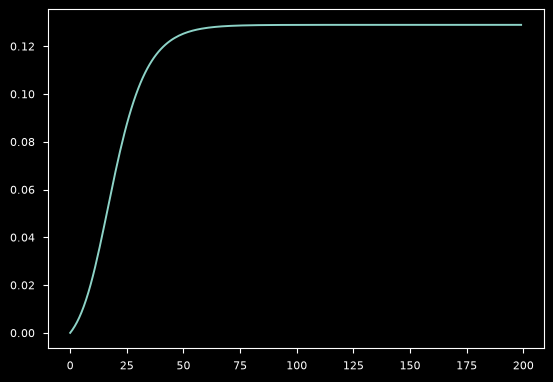

In [20]:
nonS = np.array([0.05,0.10,0.47,0.01,0.01,1e-9,1e-9,1e-9])
y0 = np.array([1.0 - np.sum(nonS), *nonS])
p = (0.8,0.7,0.2,0.2,0.05,0.35,0.25,0.2)
ts = np.arange(200.)

solution = diffeqsolve(odeterm, odesolver, t0=ts[0], t1=ts[-1], dt0=None, y0=y0, 
                       args=p,
                       saveat=SaveAt(ts=ts), 
                       stepsize_controller=odestepsize)
totals = solution.ys
plt.plot((totals[:,8]));

In [ ]:

# Note to self: vector-valued inputs to parameters for univariate distributions yields one distribution for each value
# which is used when you evaluate for each particle
us_population = 320*10**6
class FluPart(ssm.StateSpaceModel):

    default_params = {'beta_A':0.8,'beta_B':0.7,'gamma_A':0.2,'gamma_B':0.2,'epsilon':0.05,
                    'theta_A':0.35,'theta_B':0.25,'mu':0.2,'sigma_meas':0.1}

    def PX0(self):  # Distribution of X_0
        nonS = np.array([0.05,0.10,0.47,0.001,0.001,0,0,0,1e-9,1e-9])
        y0 = np.array([1.0 - np.sum(nonS), *nonS])
        component_distributions = [dists.Dirac(loc=y0[j]) for j in range(y0.shape[0])]
        return dists.IndepProd(*component_distributions)

    def PX(self, t, xp):  # Distribution of X_t given X_{t-1}=xp (p=past)
        p = [self.beta_A, self.beta_B, self.gamma_A, self.gamma_B, self.epsilon, self.theta_A, self.theta_B, self.mu]
        totals = batch_onestep(xp, p)
        component_distributions = [dists.Dirac(loc=totals[:, j]) for j in range(totals.shape[1])]
        return dists.IndepProd(*component_distributions)
        
    def PY(self, t, xp, x):  # Distribution of Y_t given X_t=x (and possibly X_{t-1}=xp)
        ## xp is unavailable at t0
        y_A = x[:,9]*us_population/10**5 if xp is None else (x[:,9] - xp[:,9])*us_population/10**5
        y_B = x[:,10]*us_population/10**5 if xp is None else (x[:,10] - xp[:,10])*us_population/10**5
        lognorms = [dists.LogNormal(mu=np.log(y_A+1e-9), sigma=self.sigma_meas), dists.LogNormal(mu=np.log(y_B+1e-9), sigma=self.sigma_meas)]
        return dists.IndepProd(*lognorms)


In [22]:
## simulate using ssm

model = FluPart()
x, y = model.simulate(200)


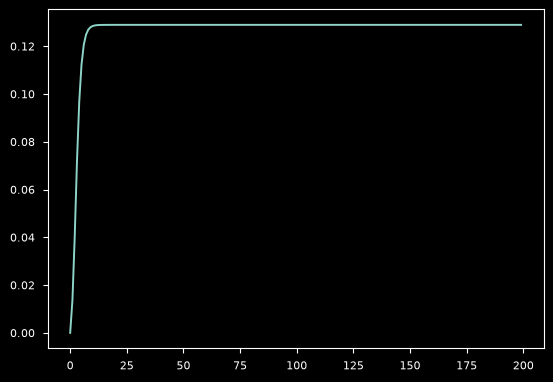

In [23]:
plt.plot(np.array(x).squeeze()[:,8]);

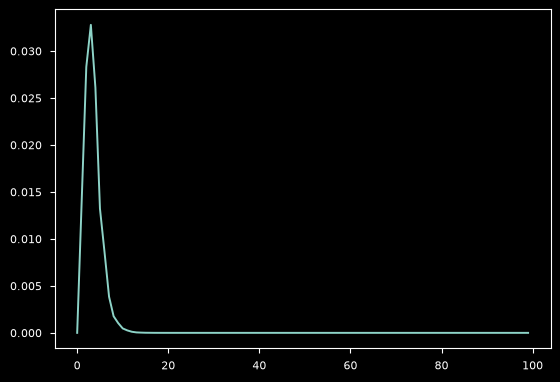

In [24]:
sim_data = np.array(y)[:100]
plt.plot(sim_data);

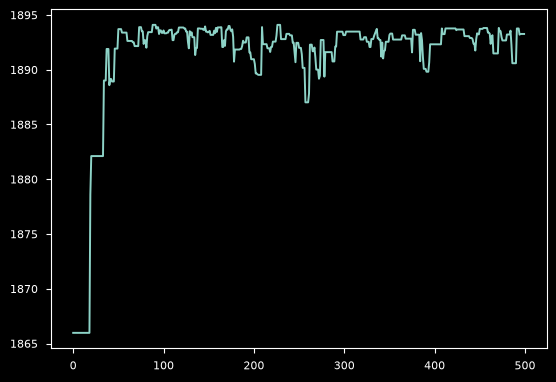

In [ ]:

#construct a prior for our model

##
## note: sampling fails with any dirac priors
## for fixed params, leave out of prior and set inside model
##
prior_dict = {
        "beta_A": dists.Gamma(4.0,6.0),  # likely using alpha-beta parametrization, mean = a/b
        "beta_B": dists.Gamma(4.0,6.0),
        "theta_A": dists.Beta(21.0,40.0),
        "theta_B": dists.Beta(21.0,40.0),
        "sigma_meas": dists.Gamma(10.0,100.0)
        }

# definition of model and prior
my_prior = dists.StructDist(prior_dict)

# perform filtering
pmmh = mcmc.PMMH(ssm_cls=FluPart, prior=my_prior, data=sim_data, Nx = 100, niter = 500)
pmmh.run();
#print(pmmh.chain.lpost)
plt.plot(pmmh.chain.lpost);

# # perform filtering for full problem
# pmmh = mcmc.PMMH(ssm_cls=FluPart, prior=my_prior, data=both_strain_incident, Nx=50, niter = 5000)
# pmmh.run()
# plt.plot(pmmh.chain.lpost)


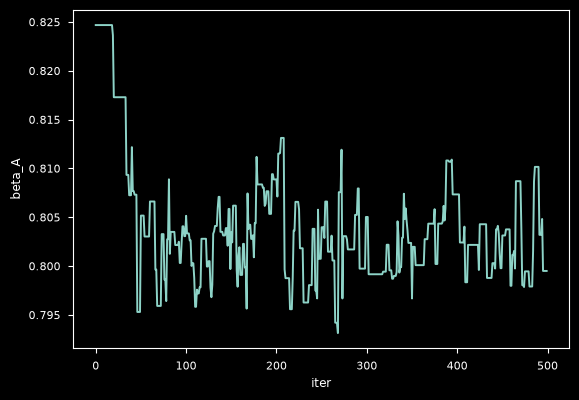

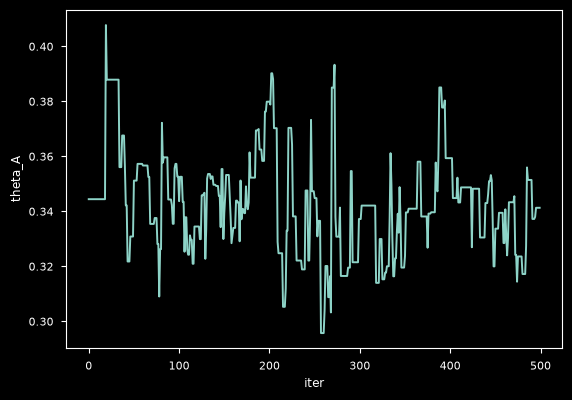

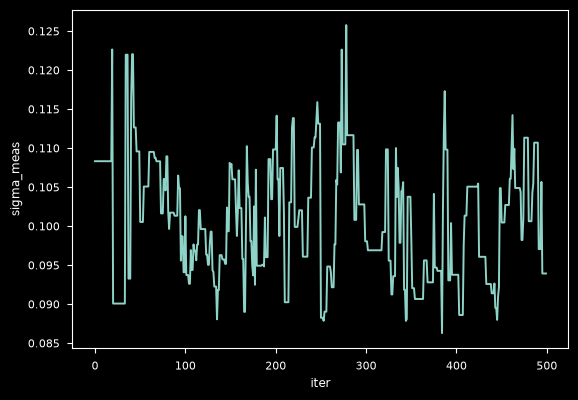

In [26]:
for p in prior_dict.keys():  # loop over mu, theta, rho
     plt.figure()
     plt.plot(pmmh.chain.theta[p])
     plt.xlabel('iter')
     plt.ylabel(p)
     plt.show()

In [ ]:
# acquire data
cwd = os.getcwd()
datafile = os.path.join(cwd, "nbeats_flu", "data", "FluSurveillance_Custom_Download_Data.csv")

# cumulative rate hospitalized is per one hundred thousand
usecols=["YEAR", "WEEK", "AGE CATEGORY", "RACE CATEGORY", "SEX CATEGORY", "VIRUS TYPE CATEGORY", "CUMULATIVE RATE"]
df = pd.read_csv(datafile, usecols=usecols)
overall_data = df[df["AGE CATEGORY"]=="Overall"]
overall_data = overall_data[overall_data["RACE CATEGORY"]=="Overall"]
overall_data = overall_data[overall_data["SEX CATEGORY"]=="Overall"].reset_index(drop=True)
flu_A = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Influenza A"].reset_index(drop=True)
flu_B = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Influenza B"].reset_index(drop=True)
both = overall_data[overall_data["VIRUS TYPE CATEGORY"]=="Overall"].reset_index(drop=True)

flu_A_cases = np.array(flu_A["CUMULATIVE RATE"])
flu_A_incident = np.diff(flu_A_cases[30:60], prepend=0.0) + 1e-9 # 30:60 is 2010 flu season
flu_B_cases = np.array(flu_B["CUMULATIVE RATE"])
flu_B_incident = np.diff(flu_B_cases[30:60], prepend=0.0) + 1e-9
both_cases = np.array(both["CUMULATIVE RATE"])
time_series = both_cases[30:60]
incident_cases = np.diff(time_series, prepend=0.0)
both_strain_incident = np.stack([flu_A_incident, flu_B_incident])


FileNotFoundError: [Errno 2] No such file or directory: 'FluSurveillance_Custom_Download_Data.csv'